# 04 · Few-Shot Identification of a New System

Chapter 03 packaged 20 long recordings into a two-dimensional family: an average system $\bar\eta$,
two directions $U$, and a noise level $\hat\sigma$. This chapter puts that backbone to work on a
*brand new* system, seen through only a couple of seconds of data.

---
## 1. From four numbers to two

For a new system we freeze $\bar\eta$ and $U$ and estimate only the context $z$. The pretraining
distribution $z\sim\mathcal N(0,I)$ is a natural prior, which gives the maximum-a-posteriori estimate

$$
\hat z = \arg\min_z \ \frac{1}{\hat\sigma^2}\sum_t \big(y_t - \hat q_t(\bar\eta + Uz;\,u)\big)^2 + \|z\|^2 .
$$

The Laplace approximation also gives an uncertainty. With $S = \partial \hat q/\partial z$ the output
sensitivity at $\hat z$,

$$
\operatorname{Cov}(z \mid \text{data}) \approx \big(\hat\sigma^{-2} S^\top S + I\big)^{-1}.
$$

Two things improve at once: there are fewer unknowns, and the prior keeps them in the region where
systems of this kind actually live.

---
## 2. Estimating the context

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.optimize import least_squares

import dynutils
from dynutils import sample_system, simulate, multisine, predict, fit_from_scratch, rmse

dynutils.set_style()
rng = np.random.default_rng(dynutils.SEED)
COLOR = dynutils.COLOR
family, train_systems, train_data, train_fits = dynutils.build_family(rng)

In [2]:
def adapt(family, y, u):
    # MAP estimate of the context, its Laplace covariance, and the RMS output misfit.
    residual = lambda z: np.r_[(predict(family.decode(z), u) - y) / family.sigma, z]
    sol = least_squares(residual, np.zeros(family.U.shape[1]))
    S = sol.jac[:-len(sol.x)] * family.sigma
    cov = np.linalg.inv(S.T @ S / family.sigma**2 + np.eye(len(sol.x)))
    misfit = rmse(predict(family.decode(sol.x), u), y)
    return sol.x, cov, misfit


def ellipse(ax, mean, cov, color, label=None, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    ax.add_patch(Ellipse(mean, *(2 * n_std * np.sqrt(vals[::-1])), angle=angle,
                         fill=False, color=color, lw=2, label=label))

---
## 3. Two seconds of data, thirty seconds of prediction

            no adaptation (average system): RMSE = 0.0563
             from scratch (4 coefficients): RMSE = 0.1580
  pretrained + adapted context (2 numbers): RMSE = 0.0140


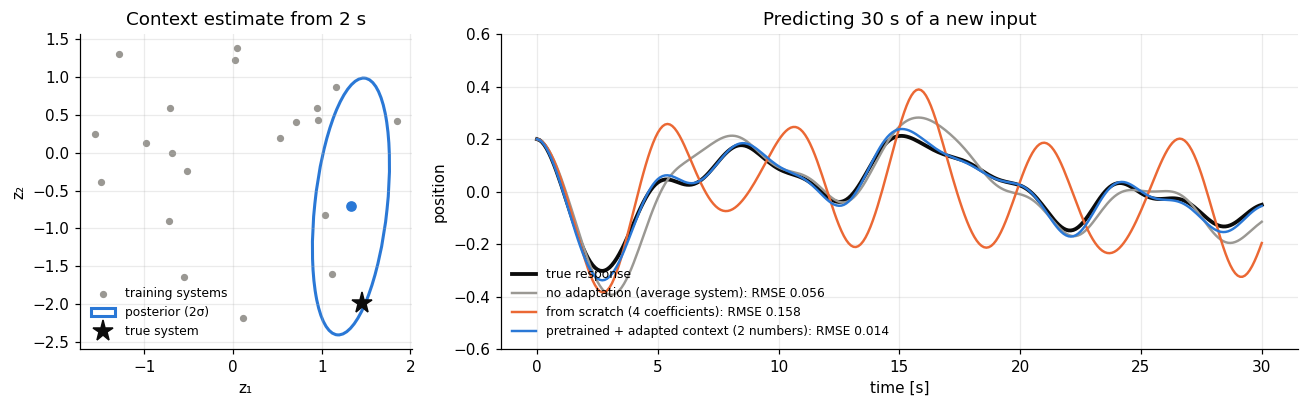

In [3]:
new = sample_system(rng)
u_short = multisine(20, rng)                           # 2 seconds of data
_, y_short = simulate(new, u_short, rng)
z_hat, z_cov, _ = adapt(family, y_short, u_short)
eta_scratch = fit_from_scratch(y_short, u_short)

u_val = multisine(300, rng, n=6)                       # a new input the model has never seen
q_val, _ = simulate(new, u_val, rng, noise=False)
models = {"no adaptation (average system)": (family.mean, COLOR["none"]),
          "from scratch (4 coefficients)": (eta_scratch, COLOR["scratch"]),
          "pretrained + adapted context (2 numbers)": (family.decode(z_hat), COLOR["context"])}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw=dict(width_ratios=[1, 2.4]))
ax1.scatter(*family.z_train.T, s=14, color=COLOR["none"], label="training systems")
ellipse(ax1, z_hat, z_cov, COLOR["context"], "posterior (2σ)")
ax1.plot(*z_hat, "o", color=COLOR["context"])
ax1.plot(*family.project(new["eta"]), "*", ms=14, color=COLOR["truth"], label="true system")
ax1.set(xlabel="z₁", ylabel="z₂", title="Context estimate from 2 s"); ax1.legend(fontsize=8)
tv = dynutils.DT * np.arange(301)
example_rmse = {name: rmse(predict(eta, u_val), q_val) for name, (eta, _) in models.items()}
for name, r in example_rmse.items():
    print(f"{name:>42s}: RMSE = {r:.4f}")
ax2.plot(tv, q_val, color=COLOR["truth"], lw=2.5, label="true response")
for name, (eta, col) in models.items():
    ax2.plot(tv, predict(eta, u_val), color=col, lw=1.6, label=f"{name}: RMSE {example_rmse[name]:.3f}")
ax2.set(xlabel="time [s]", ylabel="position", ylim=(-0.6, 0.6), title="Predicting 30 s of a new input")
ax2.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

With only two seconds of data (a third of an oscillation period), fitting four coefficients from
scratch overfits badly. It explains the short experiment, but the coefficients it finds describe a
different, barely damped oscillator, and its predictions drift far from reality. Adapting two
pretrained context values gives a model that predicts 30 seconds of unseen behaviour well. The
posterior ellipse shows how certain the estimate is, and it contains the true system.

One example proves little, so the next chapter evaluates this systematically over many new systems
and many data budgets.

---
## Exercises

### Exercise 1: A worse prior
Repeat the two-second adaptation but replace the MAP objective's prior term `z` by `3 * z` in
`adapt`'s residual (a much tighter prior, as if the family were believed to vary less than it does).
How does the estimate and its posterior ellipse change?

<details><summary>Solution</summary>

```python
def adapt_tight(family, y, u, tightness=3.0):
    residual = lambda z: np.r_[(predict(family.decode(z), u) - y) / family.sigma, tightness * z]
    sol = least_squares(residual, np.zeros(family.U.shape[1]))
    S = sol.jac[:-len(sol.x)] * family.sigma
    cov = np.linalg.inv(S.T @ S / family.sigma**2 + tightness**2 * np.eye(len(sol.x)))
    return sol.x, cov

z_tight, cov_tight = adapt_tight(family, y_short, u_short)
```
The tighter prior pulls the estimate towards the average system (`z` closer to the origin) and
shrinks the posterior ellipse, but for the wrong reason: it is now more confident without having
seen more data. With too little data to overrule a strong prior, the estimate is biased towards
$\bar\eta$ rather than towards the true system.
</details>

### Exercise 2: Does from-scratch ever catch up on this short an experiment?
Repeat the comparison above for 20 different new systems using the same 2-second experiment length,
and report the mean RMSE of "from scratch" and "pretrained + context". Does the ranking ever flip?

<details><summary>Solution</summary>

```python
errs = {"scratch": [], "context": []}
for _ in range(20):
    s = sample_system(rng); u = multisine(20, rng); _, y = simulate(s, u, rng)
    u_val = multisine(300, rng, n=6); q_val, _ = simulate(s, u_val, rng, noise=False)
    errs["scratch"].append(rmse(predict(fit_from_scratch(y, u), u_val), q_val))
    errs["context"].append(rmse(predict(family.decode(adapt(family, y, u)[0]), u_val), q_val))
{k: np.mean(v) for k, v in errs.items()}
```
Pretrained + context wins on essentially every draw at this budget; from scratch occasionally gets
close when the random 2-second input happens to be unusually informative, but it never wins by much,
and chapter 05 shows exactly how this gap closes as the budget grows.
</details>